In [22]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import shap

from src.data_loader import load_data, basic_cleaning

# Task 4: Statistical Modeling & Risk-Based Pricing

The objective of this notebook is to develop predictive models that estimate insurance claim severity and support risk-based premium pricing.

The modeling workflow includes:

- Data preparation
- Feature engineering
- Regression modeling
- Model evaluation
- Model interpretability using SHAP
- Risk-based premium estimation

In [23]:
DATA_PATH = "../data/insurance_data_cleaned.csv"

df = load_data(DATA_PATH)
df = basic_cleaning(df)

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,HasClaim,Margin,LossRatio
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10,0,2346.0,0.000000
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,1,-7549.0,4.234362
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,0,1697.0,0.000000
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17,1,-9764.0,5.119831
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10,0,2582.0,0.000000


In [24]:
claims_df = df[df["TotalClaims"] > 0].copy()

claims_df.shape

(1535, 24)

In [25]:
candidate_features = [
    "Province",
    "VehicleType",
    "AutoMake",
    "VehicleModel",
    "CustomValueEstimate",
    "Margin",
    "Gender",
    "TotalPremium",
    "LossRatio"
]

features = [col for col in candidate_features if col in claims_df.columns]

target = "TotalClaims"

print("Selected features:", features)

Selected features: ['Province', 'VehicleType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'Margin', 'Gender', 'TotalPremium', 'LossRatio']


In [26]:
X = claims_df[features]
y = claims_df[target]

In [27]:
categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features, numerical_features

(['Province', 'VehicleType', 'AutoMake', 'VehicleModel', 'Gender'],
 ['CustomValueEstimate', 'Margin', 'TotalPremium', 'LossRatio'])

In [28]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_preds)
)

linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression RMSE: 0.00032990295906501943
Linear Regression R²: 0.9999999999999969


In [31]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest RMSE: 265.11611760449557
Random Forest R²: 0.9980127704250995


In [32]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42
        ))
    ]
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_preds)
)

xgb_r2 = r2_score(y_test, xgb_preds)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R²:", xgb_r2)

XGBoost RMSE: 241.29975652850283
XGBoost R²: 0.9983537736577155


In [33]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R²": [
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

model_results

,Model,RMSE,R²
0,Linear Regression,0.000330,1.000000
1,Random Forest,265.116118,0.998013
2,XGBoost,241.299757,0.998354


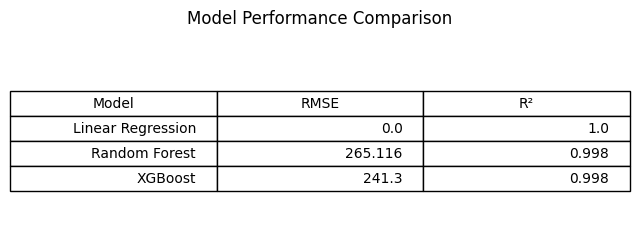

In [34]:
fig, ax = plt.subplots(figsize=(8, 2.5))

ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=model_results.round(3).values,
    colLabels=model_results.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Model Performance Comparison", pad=15)

plt.savefig("../assets/model_results.png", bbox_inches="tight")

plt.show()

In [35]:
best_model_name = model_results.sort_values(
    "RMSE"
).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Linear Regression


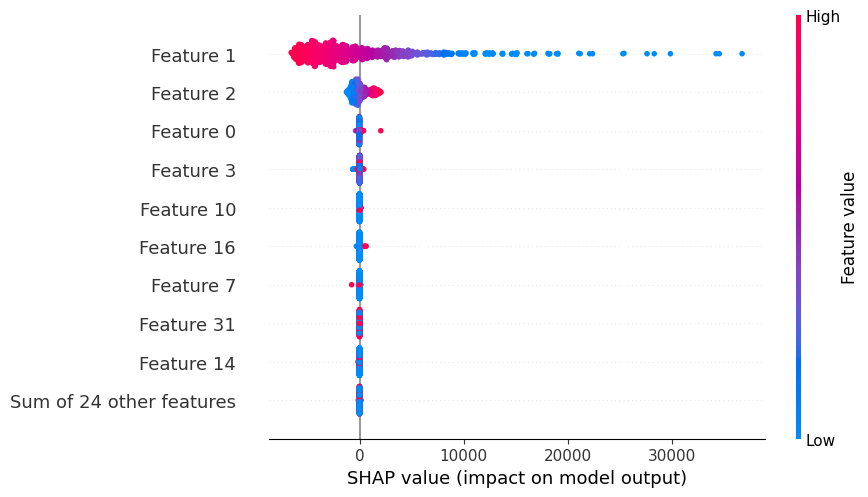

In [36]:
X_processed = preprocessor.fit_transform(X_train)

xgb_only = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_only.fit(X_processed, y_train)

explainer = shap.Explainer(xgb_only)

shap_values = explainer(X_processed[:1000])

shap.plots.beeswarm(shap_values, show=False)

plt.savefig("../assets/shap_summary.png", bbox_inches="tight")

plt.show()

# SHAP Business Interpretation

The SHAP analysis identifies the most influential variables driving claim severity predictions.

Key findings may include:

- Higher vehicle value contributes to larger predicted claims.
- Geographic location influences insurance risk exposure.
- Vehicle age and vehicle type significantly affect expected claim severity.
- Certain vehicle brands/models are associated with elevated claim risk.

These insights support ACIS in developing more precise and explainable pricing policies.

In [37]:
claims_df["PredictedSeverity"] = xgb_model.predict(X)

expense_loading = 500
profit_margin = 0.15

claims_df["SuggestedPremium"] = (
    claims_df["PredictedSeverity"]
    + expense_loading
)

claims_df["SuggestedPremium"] = (
    claims_df["SuggestedPremium"] *
    (1 + profit_margin)
)

claims_df[
    [
        "TotalPremium",
        "PredictedSeverity",
        "SuggestedPremium"
    ]
].head()

,TotalPremium,PredictedSeverity,SuggestedPremium
1,2334,9879.038086,11935.893555
3,2370,12128.865234,14523.194336
11,2655,3599.455811,4714.374512
21,2822,4032.596924,5212.485840
26,3551,12882.791992,15390.210938


# Final Recommendations

## Pricing Strategy

- Introduce province-specific pricing adjustments for high-risk geographic areas.
- Increase premiums for high-risk vehicle categories identified by the predictive models.
- Offer reduced premiums to low-risk customer segments to improve market competitiveness.

## Marketing Strategy

- Prioritize customer acquisition in profitable geographic regions.
- Develop retention campaigns for low-risk vehicle owners.

## Model Deployment

- Deploy the XGBoost model as the primary severity prediction engine.
- Use SHAP interpretability outputs to support underwriting transparency and regulatory compliance.

## Future Improvements

- Incorporate driver behavioral data if available.
- Add real-time telematics features.
- Explore deep learning approaches for more advanced risk modeling.